# Introduction to Optimization with Python

In [1]:
# Setup header
import matplotlib.pyplot as plt
import numpy as np
from pulp import *
from scipy.optimize import Bounds, LinearConstraint, NonlinearConstraint, milp, minimize, minimize_scalar
from sympy import symbols, diff, solve

## Introduction to Optimization

### Applying an objective function

Here we are doing a plot of the objective function $C(q) = 50 + 5(q - 2)^2$ where the $C(q)$ is the cost in thousands of dollars for printing $q$ thousands of magazines. Eyeballing is sufficient for minimization:

Text(0, 0.5, 'Cost ($ K)')

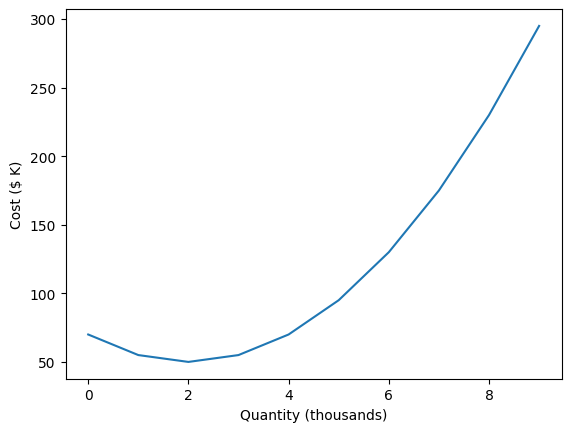

In [2]:
# Create an array of integers from 0 to 10
quantity = np.arange(10)

# Define the cost function
def cost(q): 
    return 50 + 5 * (q - 2)**2

# Plot cost versus quantity
plt.plot(quantity, cost(quantity))
plt.xlabel('Quantity (thousands)')
plt.ylabel('Cost ($ K)')

### Exhaustive search method

I was able to get the source code of the DataCamp function supplied using `??` in the IPython console:

In [3]:
def profit(q): 
    return (10 * q - 25 - q**2) + 11

# Calculate the profit for every quantity
profits = profit(quantity)

# Find the maximum profit
max_profit = max(profits)

# Find the optimal quantity
max_profit_ind = np.argmax(profits)
optimal_quantity = quantity[max_profit_ind]

# Print the results
f'You need to print {optimal_quantity * 1000} magazines to make the maximum profit of ${max_profit * 1000}.'

'You need to print 5000 magazines to make the maximum profit of $11000.'

### Finding the derivative

My first use of SymPy! `solve()` finds the sole root of the derivative:

In [4]:
# Convert q into a symbol
q = symbols('q')
c = 2000 - q**2 + 120 * q

# Find the derivative of the objective function
dc_dq = diff(c)
print(f"The derivative is {dc_dq}.")

# Solve the derivative
q_opt = solve(dc_dq)
f'Optimum quantity: {q_opt}'

The derivative is 120 - 2*q.


'Optimum quantity: [60]'

### Find the second derivative

The exercise wanted me to do `.subs()` on `d2c_dq2` but presumably in the current version of SymPy, because the result is a constant, a `SympifyError` is raised. Not sure what they were going for but apparently because the result is negative the optimum in question is a maximum:

In [5]:
# Find the second derivative
d2c_dq2 = diff(dc_dq)

# Substitute the optimum into the second derivative
# sol = d2c_dq2.subs(q, q_opt)
f'The 2nd derivative at q_opt is: {d2c_dq2}'

'The 2nd derivative at q_opt is: -2'

### Partial derivatives with SymPy

"You are an economist working for an automotive company. Your manager has modeled the production process as a function of the number of machines $K$ and the number of workers $L$ to produce $F(K, L) = -3K^2 + 100K - \frac{1}{2}L^2 + 100L$ cars. This is your multivariate objective function. You'll need to use partial derivatives to optimize this function."

In [6]:
K, L = symbols('K L')
F = -3*K**2 + 100* K - (1/2)*L**2 + 100*L

Ooh nice, automatic $\LaTeX{}$ formatting in Jupyter:

In [7]:
F

-3*K**2 + 100*K - 0.5*L**2 + 100*L

Here's how to find the critical point:

In [8]:
# Derive the partial derivatives
dF_dK = diff(F, K)
dF_dL = diff(F, L)
	
# Solve the equations
crit_points = solve((dF_dK, dF_dL), (K, L))
crit_points

{K: 16.6666666666667, L: 100.000000000000}

From [LibreTexts](https://math.libretexts.org/Bookshelves/Applied_Mathematics/Business_Calculus_with_Excel_(May_and_Bart)/06%3A_Functions_of_Several_Variables/6.03%3A_Critical_Points_and_Extrema):

"To test if a critical point is a maximum, minimum, or saddle point we compute the discriminant of the function."

In [9]:
dF_dK

100 - 6*K

In [10]:
dF_dL

100 - 1.0*L

Only two terms need to be calculated for the discriminant. (The other two are zero.)

In [11]:
dF_dK_dK = diff(dF_dK)
dF_dK_dK

-6

In [12]:
dF_dL_dL = diff(dF_dL)
dF_dL_dL

-1.00000000000000

Based on the information from the book, because $D(a, b) > 0$ and $f_{xx} < 0$ (using the book's terms), the critical point is a **maximum**.

## Unconstrained and Linear Constrained Optimization

### Finding the maxima

"Unconstrained optimization is finding the maxima or minima of a function that does not have any constraints or restrictions on the input variables.

Suppose you are launching a new product in your delicious cookie company and you want to maximize the revenue. The revenue can be modeled with this objective function where $R$ is the revenue generated at price $x$.

$R(x) = -x^2 + 3x - 5$

Solve this maximization problem using SciPy's `minimize_scalar()` which has been loaded for you."

In [13]:
# Define the new objective function
def negated_function(x):
    return -(-(x**2) + 3*x - 5)

# Maximize the negated function
result = minimize_scalar(negated_function)

# Print the result
f'The maximum is {result.x:.2f} in two decimals'

'The maximum is 1.50 in two decimals'

Not very good wording. `result.x` is really the "argmax". The actual maximum:

In [14]:
f'The (actual) maximum is {result.fun:.2f} in two decimals'

'The (actual) maximum is 2.75 in two decimals'

### Multivariate optimization

"Great job maximizing that revenue! You now want to look at minimizing costs.

You'll need to consider two variables for your new cookie product, the sugar ingredient (`a[0]`) and the flour ingredient (`a[1]`). This is a multivariate optimization problem where you want to find the best way to mix these ingredients so that your cookies are delicious but not too expensive!

SciPy's `minimize()` function has been loaded for you and the objective function has been provided."

Same thing applies here with `.x` and `.fun`:

In [15]:
def objective_function(a):
    return (a[0] - 2)**2 + (a[1] - 3)**2 + 3 

# Save your initial guess
x0 = (0, 0)

# Calculate and print the minimum
result = minimize(objective_function, x0)

print(f'The argmin is (x, y) = ({result.x[0]:.2f}, {result.x[1]:.2f}) in two decimals.')
print(f'The minimum is f(x, y) = {result.fun:.2f} in two decimals.')

The argmin is (x, y) = (2.00, 3.00) in two decimals.
The minimum is f(x, y) = 3.00 in two decimals.


### Working with Bounds

Bound-constrained problems have variables that are limited to a range of values.

You're running a coffee shop and need to place an order for two varieties of coffee beans: `b[0]` and `b[1]`. You want to minimize costs. Your supplier only accepts minimum quantity orders of 2 units for each bean, and you can afford a maximum of 100 units per bean.

`minimize` and `Bounds` from `scipy.optimize` have been loaded for you and the objective function is provided.

In [16]:
def objective_function(b):
    return (b[0] - 6)**2 + (b[1] - 8)**2 + 3

# Set the bounds of your problem
bounds = Bounds(2, 100)

x0 = (2, 2)

# Find the minimum
result = minimize(objective_function, x0, bounds=bounds)

print(f'The argmin is (x, y) = ({result.x[0]:.0f}, {result.x[1]:.0f})')
print(f'The minimum is f(x, y) = {result.fun:.0f}')

The argmin is (x, y) = (6, 8)
The minimum is f(x, y) = 3


### Handling hard inequalities

Back in the coffee shop, you want to look at minimizing daily expenses. You have an objective function that calculates your production costs, and a constraint function that tells you the limits of how much coffee you can produce.

Apply SciPy to find the optimal allocation of resources to minimize costs.

In [17]:
def objective_function(b):
    return (b[0] - 5) ** 2 + (b[1] - 3) ** 3

# NOTE: For an inequality-type constraint, the return value must be non-negative
def constraint_function(x):
    return 2*x[0] + 3*x[1] - 6

# Set the constraint variable
constraint = {'type': 'ineq',
              'fun': constraint_function}

x0 = [20, 20]

# Find the minimum
result = minimize(objective_function, x0, constraints=[constraint])

result

 message: Inequality constraints incompatible
 success: False
  status: 4
     fun: -5596424370440672.0
       x: [ 2.665e+05 -1.775e+05]
     nit: 3
     jac: [ 0.000e+00  9.456e+10]
    nfev: 9
    njev: 3

The crucial thing here appears to be `success: False`, along with `message: Inequality constraints incompatible`. The values of keys `fun` and `x` don't really need interpretation I suppose.

### PuLP for linear optimization

A farmer faces a diet problem for their cattle. The vet's recommendation is that each animal is fed at least 7 pounds of a mix of corn and soybean with at least 17% protein and 2% fat. Below are the relevant nutritional elements:

| Food type | Cost ($/lb) | Protein (%) | Fat (%) |
|-----------|-------------|-------------|---------|
| corn | 0.11 | 10 | 2.5 |
| soybean | 0.28 | 40 | 1 |

You will use this information to minimize costs subject to nutritional constraints.

`pulp` has been imported for you. \[Rather, imported by *me*.\]

In [18]:
# Define the model
model = LpProblem('MinCost', LpMinimize) 

# Define the variables
C = LpVariable('C', lowBound=0)
S = LpVariable('S', lowBound=0) 

# Add the objective function and constraints
model += 0.11 * C + 0.28 * S
model += 0.10 * C + 0.4 * S >= 0.17 * (C + S), 'M_protein'
model += 0.025 * C + 0.01 * S >= 0.02 * (C + S), 'M_fat'
model += C + S >= 7, 'M_weight'

# Solve the model
model.solve()
print(f'Cost = {value(model.objective):.2f}')
print(f'Pounds of corn = {C.varValue:.2f}, pounds of soybean = {S.varValue:.2f}')

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/readyready15728/programming/python/datacamp-python-notebooks/venv/lib/python3.10/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/92e6d49f9e284967a8835f8d48f91d5c-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/92e6d49f9e284967a8835f8d48f91d5c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 17 RHS
At line 21 BOUNDS
At line 22 ENDATA
Problem MODEL has 3 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 3 (0) rows, 2 (0) columns and 6 (0) elements
0  Obj 0 Primal inf 6.9999999 (1)
2  Obj 1.0476667
Optimal - objective value 1.0476667
Optimal objective 1.047666667 - 2 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00   (Wallclock seconds):       0.01

Cost = 1.05
Pounds of cor

The farmer wants to replicate the previous optimization function to detail with more complicated meals for other animals on the farm.

The previous code has been provided. Can you adjust the previous code to make it better at handling multiple variables?

In [19]:
model = LpProblem('MinCost', LpMinimize)

# Adjust the variable definition
variables = LpVariable.dicts('Food', ['C', 'S'], lowBound=0)

# Adjust the objective function
cost = {'C': 0.11, 'S': 0.28}
model += lpSum([cost[i] * variables[i] for i in ['C', 'S']])

model += 0.1 * variables['C'] + 0.4 * variables['S'] >= 0.17 * (variables['C'] + variables['S']), 'M_protein'
model += 0.025 * variables['C'] + 0.01 * variables['S'] >= 0.02 * (variables['C'] + variables['S']), 'M_fat'
model += variables['C'] + variables['S'] >= 7, 'M_weight'

model.solve()
print(f'Cost = {value(model.objective):.2f}')
print(f"Pounds of corn = {variables['C'].varValue:.2f}, pounds of soybean = {variables['S'].varValue:.2f}")

<class 'dict'>
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/readyready15728/programming/python/datacamp-python-notebooks/venv/lib/python3.10/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/31c72a76d8114012b233abf3a2def7be-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/31c72a76d8114012b233abf3a2def7be-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 17 RHS
At line 21 BOUNDS
At line 22 ENDATA
Problem MODEL has 3 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 3 (0) rows, 2 (0) columns and 6 (0) elements
0  Obj 0 Primal inf 6.9999999 (1)
2  Obj 1.0476667
Optimal - objective value 1.0476667
Optimal objective 1.047666667 - 2 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00   (Wallclock seconds):       0.00

Cost = 1.0

## Non-Linear Constrained Optimization

### Visualize the indifference curve

You have been provided the following utility function and constraint:

$$
\begin{align}
U(c, m) &= c^{0.7}m^{0.4} \\
c + m &= 2
\end{align}
$$

Use this to visualize the indifference curve.

\[`np` and `plt` have been loaded by me.\]

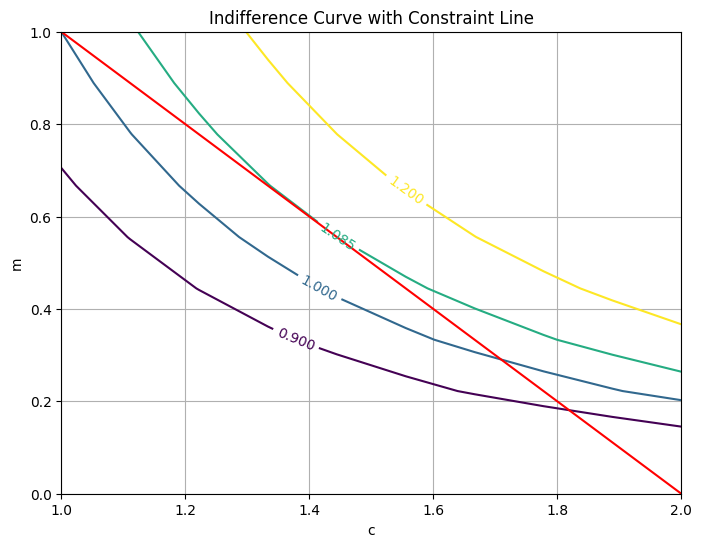

In [20]:
c = np.linspace(1, 2, 10)  
# Define the constraint and generate combinations
m = 2 - c 
C, M = np.meshgrid(c, m)
# Define the utility function
F = C**0.7 * M**0.3

plt.figure(figsize=(8, 6))
# Plot the controls and constraints
contours = plt.contour(C, M, F, levels=[0.9, 1.00, 1.085, 1.2])
plt.clabel(contours)
plt.plot(c, m, color='red')
plt.title('Indifference Curve with Constraint Line')
plt.xlabel('c')
plt.ylabel('m')
plt.grid(True)
plt.show()

### Utility maximization

Bill is an aspiring piano student who allocates hours of study in classical ($c$) and modern ($m$) music. His preferences are represented by the same utility function you just plotted:

$U(c, m) = c^{0.7}m^{0.3}$

Hours of study sum up to 2 ($c + m = 2$) daily. Help Bill find the optimal studying plan.

\[`np` and `minimize` have been loaded by me.\]

In [21]:
# Define the utility function
def utility_function(vars):
    c, m = vars
    return -(c**0.7 * m**0.3)

# Define the constraint function
def constraint(vars):
    return 2 - np.sum(vars)

initial_guess = (0, 0)

# Set up the constraint
constraint_definition = {'type': 'eq', 'fun': constraint}

# Perform optimization
result = minimize(utility_function, initial_guess, constraints=constraint_definition)
c, m = result.x

print("Optimal study hours for classical music:", round(c, 2))
print("Optimal study hours for modern music:", round(m, 2))

Optimal study hours for classical music: 1.4
Optimal study hours for modern music: 0.6


### Linear constrained biscuits

Congratulations! Your biscuit business has expanded. You now have two bakeries, $A$ and $B$, to help you deliver your biscuits nationwide.

Your bakeries can each make 100 biscuits a day and the cost of making a biscuit in bakery $A$ is $1.5q$ while in bakery $B$ it is $1.75q$.

Price is defined by $150 - q$.

Your business is booming and you already have 140 biscuit pre-orders for the day. You want to maximize your profit for the day. How many biscuits should you make in each bakery?

\[`minimize`, `Bounds`, and `LinearConstraint` have been loaded by me\] and the revenue function `R` is already defined.

In [22]:
def R(q):
    return (150 - q[0] - q[1]) * (q[0] + q[1])

# Define the cost function
def C(q): 
  return 1.5 * q[0] + 1.75 * q[1]

# Define the profit function
def profit(q): 
  return R(q) - C(q)

# Define the bounds and constraints
bounds = Bounds([0, 0], [100, 100])
constraints = LinearConstraint([1, 1], lb=140)

# Perform optimization
result = minimize(lambda q: -profit(q),
                  [50, 50],              
                  bounds=bounds,
                  constraints=constraints)

print(result.message)
print(f'The optimal number of biscuits to bake in bakery A is: {result.x[0]:.2f}')
print(f'The optimal number of biscuits to bake in bakery B is: {result.x[1]:.2f}')
print(f'The bakery company made: ${-result.fun:.2f}')

Optimization terminated successfully
The optimal number of biscuits to bake in bakery A is: 100.00
The optimal number of biscuits to bake in bakery B is: 40.00
The bakery company made: $1180.00


### Nonlinear constrained biscuits

That was some excellent baking!

Now can you solve the same problem again using `NonlinearConstraint`?

Recall the constraint for the bakeries is they need to fulfill a minimum of 140 pre-orders and each factory can make 100 biscuits daily.

\[`minimize`, `Bounds`, and `NonlinearConstraint` have been loaded by me\] as well as the revenue function `R`, cost function `C`, and profit function `profit`.

In [23]:
# Redefine the problem with NonlinearConstraint
constraints = NonlinearConstraint(lambda q: q[0] + q[1], lb=140, ub=np.inf)

# Perform optimization
result = minimize(lambda q: -profit(q), 
                  [50, 50], 
                  bounds=Bounds([0, 0], [100, 100]),
                  constraints=constraints)

print(result.message)
print(f'The optimal number of biscuits to bake in bakery A is: {result.x[0]:.2f}')
print(f'The optimal number of biscuits to bake in bakery B is: {result.x[1]:.2f}')
print(f'The bakery company made: ${-result.fun:.2f}')

Optimization terminated successfully
The optimal number of biscuits to bake in bakery A is: 100.00
The optimal number of biscuits to bake in bakery B is: 40.00
The bakery company made: $1180.00


### Adjusting MILP

The gown and tuxedo firm have adjusted some aspects of their business and need you to optimize for profit based on the new structure.

The profit formula was $545g + 330t$, where $g$ are the gowns, and $t$ are the tuxedos. The constraints are the same:

$$
\begin{align}
6g + 4t &\le 40 \\
3g + t &\le 20
\end{align}
$$

The firm wants to increase their tuxedo profit by 10%, and Mr. S can now only work 30 hours per week.

\[`milp`, `LinearConstraint` and `Bounds` have been loaded by me.\]

In [24]:
# Adjust the objective
result = milp([-545, -363],
              integrality=[1, 1],
              bounds=Bounds([0, 0], [20, 12]), 
# Change Mr. Souster's constraint limit
              constraints=LinearConstraint([[6, 4], [3, 1]], ub=[30, 20]))

print(result.message)
print(f'The optimal number of gowns produced is: {result.x[0]:.2f}')
print(f'The optimal number of tuxedos produced is: {result.x[1]:.2f}')
print(f'The firm made: ${-result.fun:.2f}')

Optimization terminated successfully. (HiGHS Status 7: Optimal)
The optimal number of gowns produced is: 5.00
The optimal number of tuxedos produced is: -0.00
The firm made: $2725.00


## Robust Optimization Techniques

### Solving the capital budgeting problem

Recall the capital budgeting problem.

Your manager designs the firm's strategy and considers projects $A$, $B$, $C$, and $A$ is the prerequisite for $B$. Profits are respectively $V = [250, 200, 300]$, the required investment is $I = [2000, 1900, 2500]$ and only \\$4600 is available. $o$ is a binary variable of whether a project is selected.

Your manager gave you the problem:

$$
\text{max} \, o_Av_A + o_Bv_B + o_Cv_C \, \text{s.t.} \, o_AI_A + o_{AB}I_B + o_CI_C \le 4600
$$

Your task is to linearize and solve the profit problem.

\[I have already imported `pulp`\] and defined a `model` with the parameters `V`, `I`, `names` for the project names ("A", "B", "C", and "AB" indexed in that order), and $o$ representing the binary decision using the same indexing.

In [25]:
V = [250, 200, 300]
I = [2000, 1900, 2500]
names = ['A', 'B', 'C', 'AB']